In [ ]:
# Section 1: Import libraries

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [ ]:
# Section 2: Loading the best master dataset

df = pd.read_csv("/content/master_dataset_v2.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (72337, 25)
            geoid stateabbr statedesc countyname  countyfips   tractfips  \
0  10011001020100        AL   Alabama    Autauga        1001  1001020100   
1  10011001020200        AL   Alabama    Autauga        1001  1001020200   
2  10011001020300        AL   Alabama    Autauga        1001  1001020300   
3  10011001020400        AL   Alabama    Autauga        1001  1001020400   
4  10011001020500        AL   Alabama    Autauga        1001  1001020500   

   totalpopulation  pct_low_food_access  pct_obesity  pct_diabetes  ...  \
0             1912                 10.2         38.7          11.0  ...   
1             2170                 13.7         45.0          13.7  ...   
2             3373                 11.4         39.4          11.5  ...   
3             4386                  7.9         34.8          10.3  ...   
4            10766                  8.4         36.3           8.9  ...   

   pct_heart_disease  pct_copd  pct_asthma  pct_depression  \
0  

In [ ]:
# Section 3: Keeping only Kansas City Metro counties using county + state

kc_pairs = [
    ("Johnson", "KS"),
    ("Leavenworth", "KS"),
    ("Miami", "KS"),
    ("Wyandotte", "KS"),
    ("Cass", "MO"),
    ("Clay", "MO"),
    ("Jackson", "MO"),
    ("Platte", "MO"),
    ("Ray", "MO")
]

df["county_state"] = list(zip(df["countyname"], df["stateabbr"]))
df = df[df["county_state"].isin(kc_pairs)].copy()

print("Kansas City dataset shape:", df.shape)
print(df[["stateabbr", "countyname"]].drop_duplicates().sort_values(["stateabbr", "countyname"]))

Kansas City dataset shape: (497, 26)
      stateabbr   countyname
26373        KS      Johnson
26519        KS  Leavenworth
26563        KS        Miami
26841        KS    Wyandotte
37295        MO         Cass
34872        MO         Clay
37558        MO      Jackson
35188        MO       Platte
38043        MO          Ray


In [ ]:
# Section 4: Select features based on project objective

features = [
    "pct_low_food_access",
    "pct_obesity",
    "pct_diabetes",
    "pct_high_blood_pressure",
    "pct_disability",
    "pct_smoking",
    "pct_no_physical_activity",
    "pct_binge_drinking",
    "pct_heart_disease",
    "pct_copd",
    "pct_asthma",
    "pct_depression",
    "pct_poor_mental_health",
    "pct_poor_physical_health",
    "pct_regular_checkup",
    "pct_short_sleep",
    "pct_stroke"
]

print("Number of selected features:", len(features))
print(features)

Number of selected features: 17
['pct_low_food_access', 'pct_obesity', 'pct_diabetes', 'pct_high_blood_pressure', 'pct_disability', 'pct_smoking', 'pct_no_physical_activity', 'pct_binge_drinking', 'pct_heart_disease', 'pct_copd', 'pct_asthma', 'pct_depression', 'pct_poor_mental_health', 'pct_poor_physical_health', 'pct_regular_checkup', 'pct_short_sleep', 'pct_stroke']


In [ ]:
# Section 5: Handle missing values

for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
print(df[features].isnull().sum())

Missing values after cleaning:
pct_low_food_access         0
pct_obesity                 0
pct_diabetes                0
pct_high_blood_pressure     0
pct_disability              0
pct_smoking                 0
pct_no_physical_activity    0
pct_binge_drinking          0
pct_heart_disease           0
pct_copd                    0
pct_asthma                  0
pct_depression              0
pct_poor_mental_health      0
pct_poor_physical_health    0
pct_regular_checkup         0
pct_short_sleep             0
pct_stroke                  0
dtype: int64


In [ ]:
# Section 6: Extract latitude and longitude from geolocation

def get_lat_lon(point_text):
    try:
        point_text = str(point_text).replace("POINT (", "").replace(")", "")
        lon, lat = point_text.split()
        return pd.Series([float(lat), float(lon)])
    except:
        return pd.Series([np.nan, np.nan])

df[["latitude", "longitude"]] = df["geolocation"].apply(get_lat_lon)

print(df[["geolocation", "latitude", "longitude"]].head())

                            geolocation   latitude  longitude
26373    POINT (-94.677029 38.84002999)  38.840030 -94.677029
26378   POINT (-94.6185999 39.03566169)  39.035662 -94.618600
26379  POINT (-94.63972295 39.03677618)  39.036776 -94.639723
26380  POINT (-94.65047781 39.03175984)  39.031760 -94.650478
26381  POINT (-94.66376248 39.03367364)  39.033674 -94.663762


In [ ]:
# Section 6: Extract latitude and longitude from geolocation

def get_lat_lon(point_text):
    try:
        point_text = str(point_text).replace("POINT (", "").replace(")", "")
        lon, lat = point_text.split()
        return pd.Series([float(lat), float(lon)])
    except:
        return pd.Series([np.nan, np.nan])

df[["latitude", "longitude"]] = df["geolocation"].apply(get_lat_lon)

print(df[["geolocation", "latitude", "longitude"]].head())

                            geolocation   latitude  longitude
26373    POINT (-94.677029 38.84002999)  38.840030 -94.677029
26378   POINT (-94.6185999 39.03566169)  39.035662 -94.618600
26379  POINT (-94.63972295 39.03677618)  39.036776 -94.639723
26380  POINT (-94.65047781 39.03175984)  39.031760 -94.650478
26381  POINT (-94.66376248 39.03367364)  39.033674 -94.663762


In [ ]:
# Section 7: Normalize all features

scaler = MinMaxScaler()

df_norm = df.copy()
df_norm[features] = scaler.fit_transform(df[features])

print("Normalization completed")
print(df_norm[features].head())

Normalization completed
       pct_low_food_access  pct_obesity  pct_diabetes  \
26373             0.057534     0.082278      0.097902   
26378             0.065753     0.101266      0.125874   
26379             0.126027     0.174051      0.101399   
26380             0.104110     0.126582      0.097902   
26381             0.136986     0.107595      0.069930   

       pct_high_blood_pressure  pct_disability  pct_smoking  \
26373                 0.191489        0.065657     0.090909   
26378                 0.269504        0.131313     0.081505   
26379                 0.182033        0.161616     0.159875   
26380                 0.198582        0.133838     0.125392   
26381                 0.118203        0.146465     0.137931   

       pct_no_physical_activity  pct_binge_drinking  pct_heart_disease  \
26373                  0.060325            0.477528           0.166667   
26378                  0.076566            0.449438           0.277778   
26379                  0.122970 

In [ ]:
# Section 8: Method 1 - Equal Weight

df_norm["method1_equal_weight"] = df_norm[features].mean(axis=1)

print(df_norm[["method1_equal_weight"]].head())

       method1_equal_weight
26373              0.154803
26378              0.184874
26379              0.212678
26380              0.194515
26381              0.190594


In [ ]:
# Section 9: Method 2 - Expert Weighted

weights = {col: 1 for col in features}

priority_vars = [
    "pct_low_food_access",
    "pct_obesity",
    "pct_diabetes",
    "pct_high_blood_pressure",
    "pct_disability"
]

for col in priority_vars:
    weights[col] = 2

total = sum(weights.values())
weights = {k: v / total for k, v in weights.items()}

df_norm["method2_expert_weighted"] = 0

for col in features:
    df_norm["method2_expert_weighted"] += df_norm[col] * weights[col]

print(df_norm[["method2_expert_weighted"]].head())

       method2_expert_weighted
26373                 0.142114
26378                 0.174389
26379                 0.198211
26380                 0.180353
26381                 0.173604


In [ ]:
# Section 10: Method 3 - AHP

ahp_weights = {
    "pct_low_food_access": 0.12,
    "pct_obesity": 0.10,
    "pct_diabetes": 0.10,
    "pct_high_blood_pressure": 0.09,
    "pct_disability": 0.08,
    "pct_smoking": 0.07,
    "pct_no_physical_activity": 0.06,
    "pct_binge_drinking": 0.05,
    "pct_heart_disease": 0.06,
    "pct_copd": 0.04,
    "pct_asthma": 0.03,
    "pct_depression": 0.05,
    "pct_poor_mental_health": 0.04,
    "pct_poor_physical_health": 0.04,
    "pct_regular_checkup": 0.03,
    "pct_short_sleep": 0.02,
    "pct_stroke": 0.02
}

df_norm["method3_ahp"] = 0

for col in features:
    df_norm["method3_ahp"] += df_norm[col] * ahp_weights[col]
print(df_norm[["method3_ahp"]].head())

       method3_ahp
26373     0.134310
26378     0.166122
26379     0.193862
26380     0.174838
26381     0.169333


In [ ]:
# Section 11: Method 4 - Rank Based

rank_feature_cols = []

for col in features:
    rank_col = col + "_feature_rank"
    df_norm[rank_col] = df_norm[col].rank(pct=True)
    rank_feature_cols.append(rank_col)

df_norm["method4_rank_based"] = df_norm[rank_feature_cols].mean(axis=1)

print(df_norm[["method4_rank_based"]].head())

       method4_rank_based
26373            0.146408
26378            0.211268
26379            0.256953
26380            0.224701
26381            0.219671


In [ ]:
# Section 12: Compare the four methods

methods = [
    "method1_equal_weight",
    "method2_expert_weighted",
    "method3_ahp",
    "method4_rank_based"
]

print(df_norm[methods].describe())

       method1_equal_weight  method2_expert_weighted  method3_ahp  \
count            497.000000               497.000000   497.000000   
mean               0.358695                 0.352942     0.347185   
std                0.146897                 0.154342     0.154513   
min                0.108304                 0.093084     0.088119   
25%                0.252245                 0.237614     0.232290   
50%                0.334016                 0.326454     0.320301   
75%                0.448473                 0.440181     0.436911   
max                0.806837                 0.816859     0.804504   

       method4_rank_based  
count          497.000000  
mean             0.501006  
std              0.218100  
min              0.096875  
25%              0.322997  
50%              0.490709  
75%              0.690318  
max              0.917387  


In [ ]:
# Section 13: Rank all methods

for method in methods:
    df_norm[method + "_rank"] = df_norm[method].rank(ascending=False)

print(df_norm[[m + "_rank" for m in methods]].head())

       method1_equal_weight_rank  method2_expert_weighted_rank  \
26373                      479.0                         478.0   
26378                      445.0                         444.0   
26379                      411.0                         412.0   
26380                      434.0                         437.0   
26381                      439.0                         445.0   

       method3_ahp_rank  method4_rank_based_rank  
26373             479.0                    482.0  
26378             445.0                    445.0  
26379             408.0                    405.0  
26380             433.0                    435.0  
26381             440.0                    438.0  


In [ ]:
# Section 14: Create priority classes

def classify(series):
    return pd.qcut(
        series.rank(method="first"),
        5,
        labels=["Very Low", "Low", "Moderate", "High", "Very High"]
    )

for method in methods:
    df_norm[method + "_class"] = classify(df_norm[method])

print(df_norm[[m + "_class" for m in methods]].head())

      method1_equal_weight_class method2_expert_weighted_class  \
26373                   Very Low                      Very Low   
26378                   Very Low                      Very Low   
26379                   Very Low                      Very Low   
26380                   Very Low                      Very Low   
26381                   Very Low                      Very Low   

      method3_ahp_class method4_rank_based_class  
26373          Very Low                 Very Low  
26378          Very Low                 Very Low  
26379          Very Low                 Very Low  
26380          Very Low                 Very Low  
26381          Very Low                 Very Low  


In [ ]:
# Section 14: Create priority classes

def classify(series):
    return pd.qcut(
        series.rank(method="first"),
        5,
        labels=["Very Low", "Low", "Moderate", "High", "Very High"]
    )

for method in methods:
    df_norm[method + "_class"] = classify(df_norm[method])

print(df_norm[[m + "_class" for m in methods]].head())

      method1_equal_weight_class method2_expert_weighted_class  \
26373                   Very Low                      Very Low   
26378                   Very Low                      Very Low   
26379                   Very Low                      Very Low   
26380                   Very Low                      Very Low   
26381                   Very Low                      Very Low   

      method3_ahp_class method4_rank_based_class  
26373          Very Low                 Very Low  
26378          Very Low                 Very Low  
26379          Very Low                 Very Low  
26380          Very Low                 Very Low  
26381          Very Low                 Very Low  


In [ ]:
# Section 15: Final model selection

df_norm["final_score"] = df_norm["method3_ahp"]
df_norm["final_rank"] = df_norm["method3_ahp_rank"]
df_norm["final_class"] = df_norm["method3_ahp_class"]

print(df_norm[["final_score", "final_rank", "final_class"]].head())

       final_score  final_rank final_class
26373     0.134310       479.0    Very Low
26378     0.166122       445.0    Very Low
26379     0.193862       408.0    Very Low
26380     0.174838       433.0    Very Low
26381     0.169333       440.0    Very Low


In [ ]:
# Section 16: Create final dashboard dataset

final_cols = [
    "geoid",
    "stateabbr",
    "statedesc",
    "countyname",
    "countyfips",
    "tractfips",
    "geolocation",
    "latitude",
    "longitude"
] + features + methods + [
    m + "_rank" for m in methods
] + [
    m + "_class" for m in methods
] + [
    "final_score",
    "final_rank",
    "final_class"
]

final_df = df_norm[final_cols].copy()

print("Final dataset shape:", final_df.shape)
print(final_df.head())

Final dataset shape: (497, 41)
                  geoid stateabbr statedesc countyname  countyfips  \
26373  2009120091053418        KS    Kansas    Johnson       20091   
26378  2009120091050000        KS    Kansas    Johnson       20091   
26379  2009120091050100        KS    Kansas    Johnson       20091   
26380  2009120091050200        KS    Kansas    Johnson       20091   
26381  2009120091050301        KS    Kansas    Johnson       20091   

         tractfips                       geolocation   latitude  longitude  \
26373  20091053418    POINT (-94.677029 38.84002999)  38.840030 -94.677029   
26378  20091050000   POINT (-94.6185999 39.03566169)  39.035662 -94.618600   
26379  20091050100  POINT (-94.63972295 39.03677618)  39.036776 -94.639723   
26380  20091050200  POINT (-94.65047781 39.03175984)  39.031760 -94.650478   
26381  20091050301  POINT (-94.66376248 39.03367364)  39.033674 -94.663762   

       pct_low_food_access  ...  method2_expert_weighted_rank  \
26373         

In [ ]:
# Section 17: Save outputs

dashboard_file = r"C:\Users\navya\Downloads\kc_dashboard.csv"
final_df.to_csv(dashboard_file, index=False)

top20 = final_df.sort_values("final_score", ascending=False).head(20)
top20_file = r"C:\Users\navya\Downloads\kc_top20.csv"
top20.to_csv(top20_file, index=False)

arcgis_file = r"C:\Users\navya\Downloads\kc_arcgis_final_scores.csv"
final_df.to_csv(arcgis_file, index=False)

print("Files saved successfully:")
print(dashboard_file)
print(top20_file)
print(arcgis_file)

Files saved successfully:
C:\Users\navya\Downloads\kc_dashboard.csv
C:\Users\navya\Downloads\kc_top20.csv
C:\Users\navya\Downloads\kc_arcgis_final_scores.csv


In [ ]:
# Section 18: Final summary

print("Total tracts:", len(final_df))
print("Max score:", final_df["final_score"].max())
print("Min score:", final_df["final_score"].min())
print("Average score:", final_df["final_score"].mean())

print("\nClass distribution:")
print(final_df["final_class"].value_counts())

Total tracts: 497
Max score: 0.8045041725101069
Min score: 0.08811937530878387
Average score: 0.34718481695974424

Class distribution:
final_class
Very Low     100
Very High    100
Low           99
Moderate      99
High          99
Name: count, dtype: int64


In [ ]:
# Section 19: Show top 20 priority tracts

print(top20[["geoid", "stateabbr", "countyname", "final_score", "final_rank", "final_class"]])

                  geoid stateabbr countyname  final_score  final_rank  \
26890  2020920209041100        KS  Wyandotte     0.804504         1.0   
26897  2020920209041800        KS  Wyandotte     0.797768         2.0   
26887  2020920209040800        KS  Wyandotte     0.781769         3.0   
37583  2909529095005601        MO    Jackson     0.748470         4.0   
37724  2909529095015400        MO    Jackson     0.738402         5.0   
26886  2020920209040700        KS  Wyandotte     0.730298         6.0   
26921  2020920209044004        KS  Wyandotte     0.726732         7.0   
37570  2909529095002200        MO    Jackson     0.719395         8.0   
37566  2909529095001900        MO    Jackson     0.697629         9.0   
37587  2909529095006000        MO    Jackson     0.687686        10.0   
37572  2909529095003400        MO    Jackson     0.683812        11.0   
26883  2020920209040400        KS  Wyandotte     0.681317        12.0   
26888  2020920209040900        KS  Wyandotte     0.

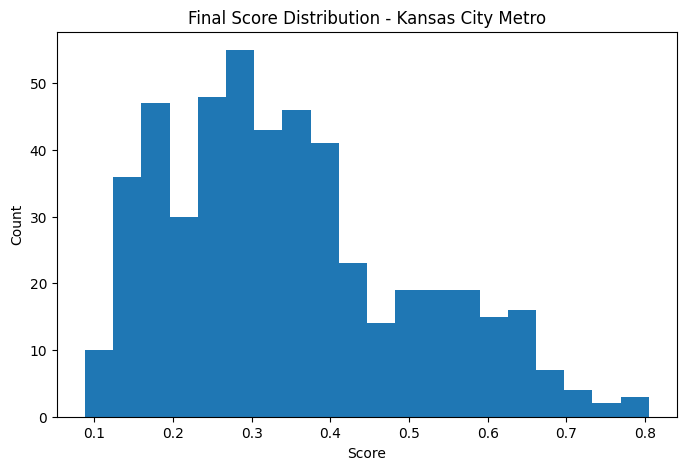

In [ ]:
# Section 20: Histogram of final score

plt.figure(figsize=(8, 5))
plt.hist(final_df["final_score"], bins=20)
plt.title("Final Score Distribution - Kansas City Metro")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

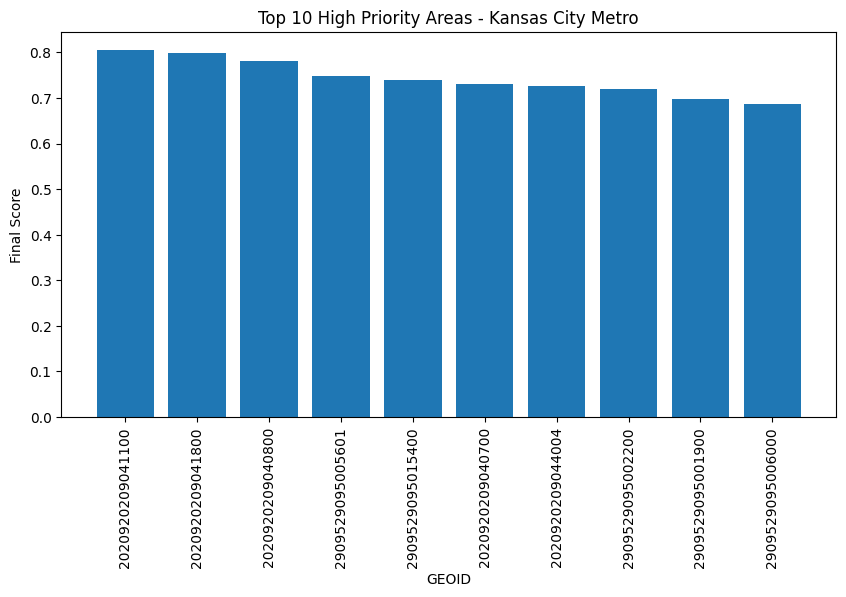

In [ ]:
# Section 21: Top 10 high priority tracts

top10 = final_df.sort_values("final_score", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10["geoid"].astype(str), top10["final_score"])
plt.xticks(rotation=90)
plt.title("Top 10 High Priority Areas - Kansas City Metro")
plt.xlabel("GEOID")
plt.ylabel("Final Score")
plt.show()

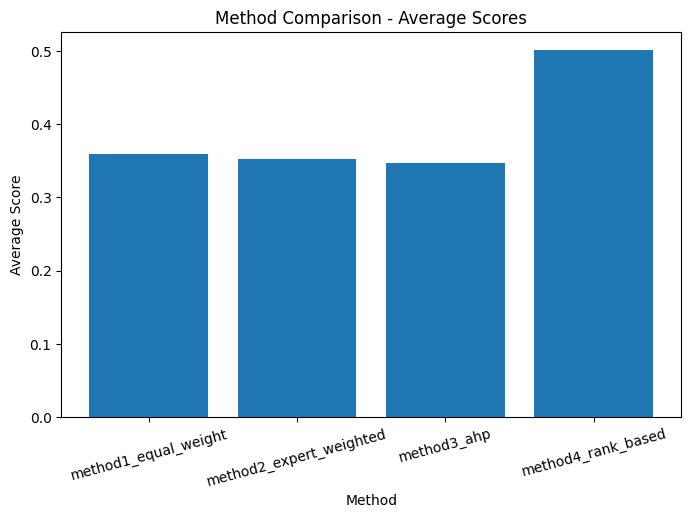

In [ ]:
# Section 22: Compare average scores of all methods

means = final_df[methods].mean()

plt.figure(figsize=(8, 5))
plt.bar(means.index, means.values)
plt.title("Method Comparison - Average Scores")
plt.xlabel("Method")
plt.ylabel("Average Score")
plt.xticks(rotation=15)
plt.show()

In [ ]:
# Section 23: Correlation between methods

print("Correlation between methods:")
print(final_df[methods].corr())

Correlation between methods:
                         method1_equal_weight  method2_expert_weighted  \
method1_equal_weight                 1.000000                 0.999230   
method2_expert_weighted              0.999230                 1.000000   
method3_ahp                          0.997506                 0.998483   
method4_rank_based                   0.974174                 0.971375   

                         method3_ahp  method4_rank_based  
method1_equal_weight        0.997506            0.974174  
method2_expert_weighted     0.998483            0.971375  
method3_ahp                 1.000000            0.971337  
method4_rank_based          0.971337            1.000000  
